# Three dojis in a row — the market's rarest "never mind" ✨
### The tri-star: candlestick lore's most legendary reversal, and its two lifetime appearances

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Tri-star_forecasts%3F: Busted](https://img.shields.io/badge/Tri--star_forecasts%3F-Busted-8b949e?style=flat-square)

A **doji** is a session where the close lands almost exactly where the open was — a coin-flip of a day, neither side wins. Most of the time it's a footnote. But candlestick lore has one truly dramatic escalation: the **tri-star** — *three* dojis in a row, each one gapping away from its neighbours like three tiny islands. Steve Nison, who brought Japanese candlesticks to the West, calls it one of the rarest patterns of all — and says when it shows up, it doesn't just pause a trend, it **ends** it.

Rare claims are fun to test, because rare means we can actually go *count* them. So we did: 61 large, liquid US stocks, 25 years of daily bars, every tri-star, both the purist's gapped version and a looser "just three dojis" reading. What we found is almost funnier than a flat no.

> 📓 **Plain-language layer.** Want the *t*-stats, the Bonferroni correction and the placebo? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** Doji = a real body no bigger than 10% of the day's high-low range (same cut the desk uses everywhere). Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from tri_star_doji import data, strategy as st

HAVE_REAL = data.have_real()
PANEL = data.load_real() if HAVE_REAL else None
print("real cache present:", HAVE_REAL, "| basket size:", len(data.BASKET))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_names': 61, 'years': 25.0, 'total_bars': 383080, 'asof': '2026-06-30', 'fp_spy': 'd1ac9e0ecaae', 'fp_panel': '7c12cddbd539', 'n_strict': 2, 'n_loose': 410, 'bonferroni_crit': 2.5, 'strict': {5: (2, -243.0, 0), 10: (2, -249.6, 0), 20: (2, -610.6, 0), 60: (2, -1355.3, 0)}, 'strict_events': [('JPM', '2021-03-17', '2021-03-19', -49.0, -215.6), ('CSCO', '2019-01-24', '2019-01-28', -1172.2, -2495.1)], 'loose': {5: (410, -14.3, 48, 2.1, -16.4, -1.02, 0.826, -16.8), 10: (410, -19.1, 47, 1.9, -20.9, -0.98, 0.807, -21.6), 20: (410, -76.6, 44, 6.2, -82.8, -2.47, 0.986, -79.1), 60: (410, -86.7, 46, 7.5, -94.1, -1.65, 0.933, -89.2)}, 'syn_null_mean': -0.6, 'syn_null_sd': 1.16, 'syn_null_fire': 4, 'syn_null_seeds': 20, 'syn_edge_002_t': 2.36, 'syn_edge_002_delta': 52.9, 'syn_edge_004_t': 5.14, 'syn_edge_004_delta': 129.3}


real cache present: True | basket size: 61


## The answer first

| Question | Answer |
|---|---|
| How rare is the *real* tri-star (gapped, as Nison defines it)? | **Two occurrences.** In **61 stocks over 25 years** (383,080 trading days total), the pattern, defined the way the book actually defines it, happened **twice**. |
| What happened after those two? | **Both lost.** JPM (March 2021) kept climbing; the 'reversal' bet cost 2.2% over the next 3 months. CSCO (January 2019) kept climbing *harder* — the bet cost 25.0%. Zero for two. |
| What if we're generous and drop the gap requirement? | It stops being rare (**410** occurrences) — but the reversal bet still **loses to a random day** at every single time horizon we checked. |
| So does stacking three dojis beat just one? | **No.** A single doji already failed this exact test in [study 405](../../../405-doji-reversal/); tripling it doesn't help. |

> Sometimes 'this pattern is legendarily rare' is candlestick-speak for 'we never actually counted how often it happens, or what happened next.'

## 1 · The claim

> *"Three dojis in a row — each one a session of pure indecision, each one gapping away from the last — is the rarest and most powerful reversal signal in candlestick charting. It doesn't just pause a trend. It ends it."* — the tri-star, per Nison's *Japanese Candlestick Charting Techniques*.

It's the natural end point of an escalation: one doji is indecision ([study 405](../../../405-doji-reversal/)); a doji marooned by gaps is an *abandoned baby* ([study 458](../../../458-abandoned-baby/)); **three** dojis, each gapped, is candlestick lore's grand finale — the market completely losing its nerve, three days running.

## 2 · So what?

If a chart pattern really *did* call major reversals, this would be as close to a free lunch as charting gets: an unmistakable, rare, high-conviction signal you could circle on a chart and act on. But "rare" cuts both ways — a pattern almost never seen is also a pattern almost never *tested*, which is exactly the soil where folklore grows unchecked. So: how rare is 'rare', actually — and on the (few) occasions it fires, does the market actually turn?

## 3 · How would we even know?

- **The basket.** SPY + **60** long-listed US large-caps across every major sector, **25 years** of daily bars each (383,080 bars total) — as broad and deep a net as we can throw at a genuinely rare pattern.
- **Two honest cuts.** The **strict** tri-star (three dojis, the middle one truly gapped clear of both neighbours — Nison's own definition) and a **loose** one (three dojis back to back, no gap required) — reported side by side, not cherry-picked.
- **The trade.** Bet *against* the 10-day trend into the tri-star at the next open — the textbook reversal — and read forward 5/10/20/60-day returns.
- **The honest bar.** Compare against the **same bet on any random day** (the base rate), and if there are too few events to test — **say so**, instead of quoting a *t*-stat computed on a handful of points.

## 4 · The teardown — let's actually look

**First: how rare is a *real* tri-star, really?**

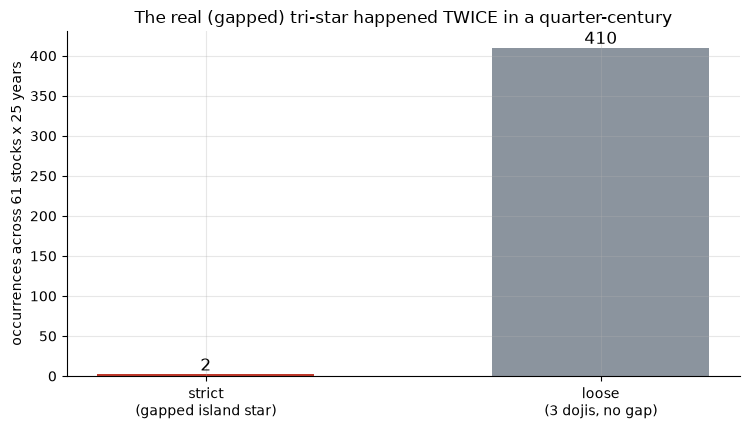

strict: 2  loose: 410  (out of 383,080 trading days pooled)


In [2]:
labels = ['strict\n(gapped island star)', 'loose\n(3 dojis, no gap)']
counts = [R['n_strict'], R['n_loose']]
fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.bar(labels, counts, color=[RED, GREY], width=.55)
for i, v in enumerate(counts): ax.annotate(str(v), (i, v), ha='center', va='bottom', fontsize=12)
ax.set_ylabel(f'occurrences across {R["n_names"]} stocks x {R["years"]:.0f} years')
ax.set_title('The real (gapped) tri-star happened TWICE in a quarter-century')
plt.tight_layout(); plt.show()
print(f"strict: {R['n_strict']}  loose: {R['n_loose']}  (out of {R['total_bars']:,} trading days pooled)")

Two. Not "rare as in a few dozen" — **two**, full stop, defined the way the book actually defines it. That alone should make anyone pause before calling it a *reliable* signal. But since it happened, let's meet them.

In [3]:
for tkr, d0, d1, r20, r60 in R['strict_events']:
    print(f'{tkr}: tri-star block {d0} -> {d1}   '
          f'20-day reversal {r20:+.1f} bps   60-day reversal {r60:+.1f} bps')

JPM: tri-star block 2021-03-17 -> 2021-03-19   20-day reversal -49.0 bps   60-day reversal -215.6 bps
CSCO: tri-star block 2019-01-24 -> 2019-01-28   20-day reversal -1172.2 bps   60-day reversal -2495.1 bps


**JPM, March 2021** — a tri-star after a run-up; the 'major reversal' bet lost **2.2%** over the next three months as JPM kept climbing. **CSCO, January 2019** — same story, worse: the bet lost **25.0%** as Cisco's early-2019 rally simply continued straight through the signal. Zero for two isn't proof of anything by itself (n=2!) — but it's the complete, honest record.

**Now the generous version.** Drop the gap requirement — allow any three dojis in a row — and the count jumps to **410**, enough to actually test. Does the reversal bet beat a random day now?

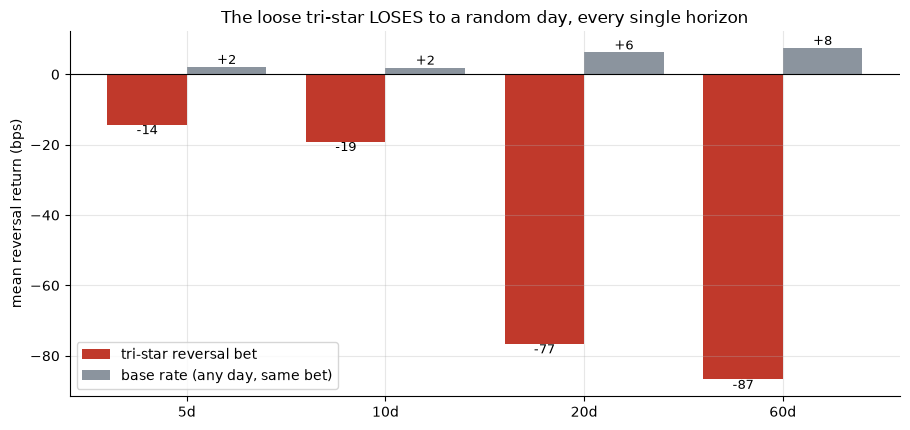

tri-star: [-14.3, -19.1, -76.6, -86.7]
base rate: [2.1, 1.9, 6.2, 7.5]


In [4]:
hs = [5, 10, 20, 60]
tri = [R['loose'][h][1] for h in hs]
base = [R['loose'][h][3] for h in hs]
fig, ax = plt.subplots(figsize=(9.2, 4.4))
x = np.arange(len(hs))
ax.bar(x-.2, tri, .4, color=RED, label='tri-star reversal bet')
ax.bar(x+.2, base, .4, color=GREY, label='base rate (any day, same bet)')
for i,(a,b) in enumerate(zip(tri,base)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='top' if a<0 else 'bottom',fontsize=9)
    ax.annotate(f'{b:+.0f}',(i+.2,b),ha='center',va='bottom',fontsize=9)
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('mean reversal return (bps)')
ax.set_title('The loose tri-star LOSES to a random day, every single horizon')
ax.legend(); plt.tight_layout(); plt.show()
print('tri-star:', tri); print('base rate:', base)

Not close, and not in the pattern's favor. At every horizon the tri-star reversal bet underperforms the base rate by **16 to 83 bps**. The quants notebook shows the strongest gap (20 days) still falls short of the desk's certification bar — and even if it hadn't, it's the *wrong sign* for the claim. A random day is a better trade than the market's most famous reversal signal.

## 5 · The verdict

- **Signal — None.** The real (gapped) tri-star fired twice in a quarter-century — both losers — too few to test. The loose reading (410 occurrences) loses to a random day at every horizon.
- **Tradability — Mirage.** Once every ~30 ticker-years is not a strategy, and there's no gross edge for costs to even threaten.
- **"Tri-star marks a major reversal"? — Busted.** Two real trades, two losses; the common reading loses to a coin flip. Stacking three dojis instead of one doesn't manufacture a signal a single doji never had.

## 6 · Going further 🚪

- **The escalation, closed out.** [Study 405](../../../405-doji-reversal/) (one doji) and [study 458](../../../458-abandoned-baby/) (one gapped doji between directional candles) both land the same place: the candlestick-of-indecision family doesn't forecast, no matter how you stack it.
- **What next?** A pattern this rare simply can't be rescued with more statistics — the binding constraint is real-world occurrence count, not method. Intraday bars would multiply the count but change the microstructure entirely.

*Think three-in-a-row is different from one? Show a tri-star reversal edge on a basket where it fires more than twice — then we'll talk.*